# Question 4 (20 points) 

<h2 style="font-weight: bold;">Recall Class 5, where we practiced scraping the course catalog; the bonus activity asked you to retrieve links to the prerequisites for courses. Now we will construct a DAG (directed acyclic graph) of the curriculum. (If we find cycles in the curriculum, we are probably in trouble.)</h2>

 <h2 style="font-weight: bold;">a) If you haven't already done so, write a function that scrapes a department's course catalog and obtains links to the prerequisites of each course.</h2>

In [21]:
import re
import time
import requests
from bs4 import BeautifulSoup
import pandas as pd
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
import networkx as nx
import matplotlib.pyplot as plt
from pyvis.network import Network
from tqdm import tqdm 
import os
import pickle

In [22]:
def fetch_page(url):
    """Fetch the HTML content of a webpage."""
    headers = {"User-Agent": "Mozilla/5.0 (compatible; scraping-bot/1.0)"}
    r = requests.get(url, headers=headers, timeout=15)
    r.raise_for_status()
    return r.text


def text_clean(s: str) -> str:
    """Clean whitespace and normalize unicode spaces."""
    if not s:
        return ""
    s = s.replace(u'\u00A0', ' ')
    s = re.sub(r'\s+', ' ', s).strip()
    return s

In [23]:
def parse_courses(course_code: str, html: str = None, verbose: bool = False):
    """
    Parse course information from Northeastern catalog.

    Parameters
    ----------
    course_code : str
        The course code (e.g., 'NETS', 'CS', 'PHYS', etc.)
    html : str, optional
        HTML content. If not provided, will fetch from the catalog URL
    verbose : bool
        Whether to print debug information

    Returns
    -------
    list of dict
        List of courses with their information
    """

    # Normalize course code (both upper and lower case versions)
    course_code_upper = course_code.upper()
    course_code_lower = course_code.lower()

    # If HTML not provided, fetch it from the catalog
    if html is None:
        url = f"https://catalog.northeastern.edu/course-descriptions/{course_code_lower}/"
        if verbose:
            print(f"Fetching courses from: {url}")
        try:
            html = fetch_page(url)
        except Exception as e:
            if verbose:
                print(f"Error fetching page: {e}")
            return []

    # Regex patterns to identify course headers
    header_find_pattern = re.compile(rf'^{course_code_upper}\s*\d{{3,4}}\b', re.IGNORECASE)
    header_full_pattern = re.compile(
        rf'^({course_code_upper}\s*\d{{3,4}})\.\s*(.+?)\s*\(([^)]+)\)\s*',
        re.IGNORECASE | re.DOTALL
    )
    header_no_credits = re.compile(
        rf'^({course_code_upper}\s*\d{{3,4}})\.\s*(.+)$',
        re.IGNORECASE | re.DOTALL
    )

    soup = BeautifulSoup(html, 'html.parser')
    main = soup.find(id="content") or soup.find("main") or soup.body

    if not main:
        if verbose:
            print("Could not find main content area")
        return []

    # Look for structured course blocks
    course_blocks = main.find_all('div', class_='courseblock')

    # Fallback: look for paragraphs if no blocks are found
    if not course_blocks:
        course_blocks = []
        for elem in main.find_all(['p', 'div']):
            text = elem.get_text(strip=True)
            if header_find_pattern.match(text):
                course_blocks.append(elem)

    courses = []

    # Process each course block
    for block in course_blocks:
        full_text = ' '.join(block.stripped_strings)
        raw_text = block.get_text(' ', strip=True)

        # Try parsing header with credits
        m = header_full_pattern.match(full_text)
        if m:
            code = text_clean(m.group(1))
            title = text_clean(m.group(2)).rstrip(".")
            credits = text_clean(m.group(3))
            rest = full_text[m.end():].strip()
        else:
            m2 = header_no_credits.match(full_text)
            if m2:
                code = text_clean(m2.group(1))
                title = text_clean(m2.group(2).split("Prerequisite")[0].split("Attribute")[0]).rstrip(".")
                credits = ""
                rest = full_text[m2.end():].strip()
            else:
                if verbose:
                    print(f"WARNING: couldn't parse block (skipping): {full_text[:300]}")
                continue

        # -------------------------
        # Extract prerequisites
        # -------------------------
        prereq = []
        prereq_match = re.search(
            r'Prerequisite(?:\(s\))?\s*:\s*(.+?)(?=(?:Attribute|Corequisite|$))',
            rest,
            flags=re.IGNORECASE | re.DOTALL
        )
        if prereq_match:
            prereq_text = text_clean(prereq_match.group(1))
            # Extract only valid course codes
            prereq = re.findall(r'[A-Z]{3,4}\s*\d{4}', prereq_text)

        # -------------------------
        # Extract attributes
        # -------------------------
        attrs = ""
        attr_match = re.search(
            r'Attribute(?:s)?\s*[:\-]?\s*(.+?)(?=$)',
            rest,
            flags=re.IGNORECASE
        )
        if attr_match:
            attrs = text_clean(attr_match.group(1)).rstrip(".")
            rest = rest.replace(attr_match.group(0), "").strip()

        # -------------------------
        # Extract corequisites
        # -------------------------
        coreq = ""
        coreq_match = re.search(
            r'Corequisite(?:\(s\))?\s*[:\-]?\s*(.+?)(?=(?:Attribute|$))',
            rest,
            flags=re.IGNORECASE
        )
        if coreq_match:
            coreq = text_clean(coreq_match.group(1)).rstrip(".")
            rest = rest.replace(coreq_match.group(0), "").strip()

        description = text_clean(rest).rstrip(".")

        courses.append({
            "code": code,
            "title": title,
            # "credits": credits,
            # "description": description,
            "prerequisites": prereq,  
            # "corequisites": coreq,
            # "attributes": attrs
        })

    return courses

In [24]:
def parse_courses_df(course_code: str, html: str = None, verbose: bool = False) -> pd.DataFrame:
    """
    Parse course information from Northeastern catalog and return as a DataFrame.

    Parameters
    ----------
    course_code : str
        The course code (e.g., 'NETS', 'CS', 'PHYS', etc.)
    html : str, optional
        HTML content. If not provided, will fetch from the catalog URL
    verbose : bool
        Whether to print debug information

    Returns
    -------
    pd.DataFrame
        DataFrame with columns: code, title, prerequisites (list)
    """
    courses = parse_courses(course_code, html, verbose)  # usa la tua funzione esistente
    if not courses:
        return pd.DataFrame(columns=["code", "title", "prerequisites"])
    
    # Convert list of dicts to DataFrame
    df = pd.DataFrame(courses)
    
    # Ensure the prerequisites column is a list even if empty
    df["prerequisites"] = df["prerequisites"].apply(lambda x: x if isinstance(x, list) else [])
    
    return df

<h2 style="font-weight: normal;font-size: 18px">Example n°1 with Applied Artificial Intelligence - CPS (AAI) </h2>

In [25]:
code = "AAI"
df_aai = parse_courses_df(code, verbose=True)
df_aai

Fetching courses from: https://catalog.northeastern.edu/course-descriptions/aai/


,code,title,prerequisites
0,AAI 1990,Elective,[]
1,AAI 2990,Elective,[]
2,AAI 3990,Elective,[]
3,AAI 4990,Elective,[]
4,AAI 5015,Mathematical Concepts,[]
5,AAI 5025,Python,[]
6,AAI 5035,Research Methods and Scientific Writing,[]
7,AAI 6600,Applied Artificial Intelligence,[]
8,AAI 6610,Applied Machine Learning,[]
9,AAI 6620,Applied Natural Language Processing,[AAI 6610]


<h2 style="font-weight: normal;font-size: 18px">Example n°2 with Bioinformatics (BINF)</h2>

In [26]:
code = "BINF"
df_binf = parse_courses_df(code, verbose=True)
df_binf

Fetching courses from: https://catalog.northeastern.edu/course-descriptions/binf/


,code,title,prerequisites
0,BINF 1990,Elective,[]
1,BINF 2990,Elective,[]
2,BINF 3990,Elective,[]
3,BINF 4990,Elective,[]
4,BINF 5964,Projects for Professionals,[]
5,BINF 5976,Directed Study,[]
6,BINF 6200,Bioinformatics Programming,[]
7,BINF 6201,Introduction to Bioinformatics Using RNA Sequencing,[]
8,BINF 6250,Algorithmic Foundations in Bioinformatics,"[BINF 6200, BINF 6200]"
9,BINF 6308,Bioinformatics Computational Methods 1,[]


<h2 style="font-weight: normal;font-size: 18px">Example n°3 with English (ENGL)</h2>

In [27]:
code = "ENGL"
df_engl = parse_courses_df(code, verbose=True)
df_engl

Fetching courses from: https://catalog.northeastern.edu/course-descriptions/engl/


,code,title,prerequisites
0,ENGL 1000,English at Northeastern,[]
1,ENGL 1140,Grammar: The Architecture of English,"[ENGL 1102, ENGL 1111, ENGW 1102, ENGW 1111, ENGW 1113, ENGW 1114]"
2,ENGL 1160,Introduction to Rhetoric,"[ENGL 1102, ENGL 1111, ENGW 1102, ENGW 1111, ENGW 1113, ENGW 1114]"
3,ENGL 1300,Introduction to Health and Humanities,[]
4,ENGL 1400,Introduction to Literary Studies,"[ENGL 1102, ENGL 1111, ENGW 1102, ENGW 1111, ENGW 1113, ENGW 1114]"
5,ENGL 1410,Introduction to Research on Writing,"[ENGL 1102, ENGL 1111, ENGW 1102, ENGW 1111, ENGW 1113, ENGW 1114]"
6,ENGL 1450,Reading and Writing in the Digital Age,"[ENGL 1102, ENGL 1111, ENGW 1102, ENGW 1111, ENGW 1113, ENGW 1114]"
7,ENGL 1502,American Literature to 1865,"[ENGL 1102, ENGL 1111, ENGW 1102, ENGW 1111, ENGW 1113, ENGW 1114]"
8,ENGL 1600,Introduction to Shakespeare,"[ENGL 1102, ENGL 1111, ENGW 1102, ENGW 1111, ENGW 1113, ENGW 1114]"
9,ENGL 1700,Global Literatures 1,"[ENGL 1102, ENGL 1111, ENGW 1102, ENGW 1111, ENGW 1113, ENGW 1114]"


<h2 style="font-weight: bold;"> b) Use this function to construct a <code>networkx</code> directed graph object of the entire curriculum, where edges point from prerequisites to the courses that require them. For example, if course $j$ requires course $i$, then we should have a directed edge $(i,j)$.</h2>

In [28]:
def build_curriculum_graph(courses):
    """
    Build a directed graph of courses where edges go from prerequisites to the course.

    Parameters
    ----------
    courses : list of dict
        Output from parse_courses(). Each course dict must contain:
        - "code": str, course code (e.g., "PHYS 5116")
        - "prerequisites": list of str, course codes that are prerequisites

    Returns
    -------
    G : nx.DiGraph
        Directed graph of the curriculum.
    """
    G = nx.DiGraph()

    for course in courses:
        code = course["code"]
        prereqs = course.get("prerequisites", [])

        # Add the course node
        G.add_node(code, title=course.get("title", ""))

        # Add edges from each prerequisite to this course
        for prereq in prereqs:
            G.add_node(prereq)  # make sure prereq node exists
            G.add_edge(prereq, code)

    return G


def visualize_graph(G: nx.DiGraph, size, notebook=True, output_file="curriculum.html"):
    """
    Visualize a directed graph using PyVis.

    Parameters
    ----------
    G : nx.DiGraph
        Directed graph to visualize
    notebook : bool
        If True, show inside Jupyter/Colab; if False, save to HTML
    output_file : str
        Path to save the interactive visualization
    """
    net = Network(height="800px", width="100%", directed=True, notebook=notebook)

    # Add nodes with labels
    for node, data in G.nodes(data=True):
        net.add_node(node, label=node, title=data.get("title", ""),size=size)

    # Add edges
    for u, v in G.edges():
        net.add_edge(u, v)
        
    net.repulsion()
    
    # Show or save
    if notebook:
        return net.show(output_file)
    else:
        net.save_graph(output_file)
        print(f"Graph saved to {output_file}")

<h2 style="font-weight: normal;font-size: 18px">Example n°1 with Applied Artificial Intelligence - CPS (AAI) </h2>

In [29]:
courses_aai = parse_courses("AAI", verbose=False)
G_aai = build_curriculum_graph(courses_aai)
visualize_graph(G_aai, notebook=True, output_file="aai_curriculum.html",size=30)

aai_curriculum.html


<h2 style="font-weight: normal;font-size: 18px">Example n°2 with Bioinformatics (BINF)</h2>

In [30]:
courses_binf = parse_courses("BINF", verbose=False)
G_binf = build_curriculum_graph(courses_binf)
visualize_graph(G_binf, notebook=True, output_file="binf_curriculum.html",size=30)

binf_curriculum.html


<h2 style="font-weight: normal;font-size: 18px">Example n°3 with English (ENGL)</h2>

In [31]:
courses_engl = parse_courses("ENGL", verbose=False)
G_engl = build_curriculum_graph(courses_engl)
visualize_graph(G_engl, notebook=True, output_file="engl_curriculum.html",size=10)

engl_curriculum.html


<h2 style="font-weight: bold;">c) Which department has the most prerequisites per course, on average? Is this surprising to you?</h2>

<h2 style="font-weight: normal;font-size: 18px">First of all, we need to extract the list of all department codes:</h2>

In [38]:
def scrape_departments(url: str):
    """
    Scrape all department names and codes from Northeastern catalog,
    cleaning invisible characters (e.g. zero-width space).

    Parameters
    ----------
    url : str
        The URL of the catalog page.

    Returns
    -------
    list of dict
        Each dict contains:
        - "name": department name (string)
        - "code": department code (string)
    """
    
    def clean_text(text: str) -> str:
        """Remove invisible characters like zero-width spaces and trim."""
        return re.sub(r"[\u200b\u200c\u200d\ufeff]", "", text).strip()

    response = requests.get(url)
    response.raise_for_status()

    soup = BeautifulSoup(response.text, "html.parser")

    departments = []
    text_lines = soup.get_text().splitlines()

    # Regex to capture all parenthesized groups
    pattern = re.compile(r"\((.*?)\)")

    for line in text_lines:
        line = clean_text(line.strip())
        if not line:
            continue

        matches = pattern.findall(line)
        if matches:
            # The last parenthesis group is the code
            code = clean_text(matches[-1])
            # The name is everything before the last '('
            name = clean_text(line.rsplit("(", 1)[0])
            departments.append({
                "name": name,
                "code": code
            })

    return departments

In [39]:
url = "https://catalog.northeastern.edu/course-descriptions/"
departments_list = scrape_departments(url)
df_departments = pd.DataFrame(departments_list)
df_departments = df_departments.drop_duplicates(subset=['name', 'code']).reset_index(drop=True)
df_departments

,name,code
0,Accounting,ACCT
1,Accounting - CPS,ACC
2,Advanced Manufacturing Systems - CPS,AVM
3,African Studies,AFRS
4,Africana Studies,AFCS
5,American Sign Language,AMSL
6,Analytics - CPS,ALY
7,Anthropology,ANTH
8,Anthropology - CPS,ANT
9,Applied Artificial Intelligence - CPS,AAI


<h2 style="font-weight: normal;font-size: 18px">And then, for each of them, calculate the average prerequisites per course.</h2>

In [48]:
def average_prerequisites_per_course(department_code: str, html: str = None, verbose: bool = False) -> float:
    """
    Calculate the average number of prerequisites per course for a given department.

    Parameters
    ----------
    department_code : str
        The department code (e.g., 'NETS', 'CS', 'PHYS', etc.)
    html : str, optional
        HTML content of the department page. If not provided, it will be fetched.
    verbose : bool
        Whether to print debug information.

    Returns
    -------
    float
        Average number of prerequisites per course.
    """

    # Use the existing parse_courses function to get all courses for the department
    courses = parse_courses(department_code, html=html, verbose=verbose)
    
    if not courses:
        if verbose:
            print(f"No courses found for department {department_code}.")
        return 0.0

    # Count prerequisites for each course
    prereq_counts = [len(course.get("prerequisites", [])) for course in courses]

    # Calculate and return the average
    average = sum(prereq_counts) / len(prereq_counts)
    if verbose:
        print(f"Department {department_code}: {len(courses)} courses with a total of {sum(prereq_counts)} prerequisites. Average prerequisites = {average:.2f}")
    return average

<h2 style="font-weight: normal;font-size: 18px">Example</h2>

In [50]:
avg_aai = average_prerequisites_per_course("AAI", verbose=True)
print("\n")
avg_binf = average_prerequisites_per_course("BINF", verbose=True)

Fetching courses from: https://catalog.northeastern.edu/course-descriptions/aai/
Department AAI: 29 courses with a total of 22 prerequisites. Average prerequisites = 0.76


Fetching courses from: https://catalog.northeastern.edu/course-descriptions/binf/
Department BINF: 23 courses with a total of 36 prerequisites. Average prerequisites = 1.57


<h2 style="font-weight: normal;font-size: 18px">Even though it would make more sense to have an integer value when talking about the average number of courses, two decimal places have been kept to capture differences that would otherwise be lost if rounded to whole numbers.</h2>


In [61]:
df_sorted = (
    df_departments.copy()
    .assign(average_prerequisites=[average_prerequisites_per_course(code) for code in df_departments['code']])
    .sort_values(by='average_prerequisites', ascending=False)
    .assign(average_prerequisites=lambda x: x['average_prerequisites'].round(2))
    .reset_index(drop=True)
)
df_sorted

,name,code,average_prerequisites
0,English,ENGL,3.47
1,Creative Writing,CRWT,3.33
2,Anthropology,ANTH,3.22
3,English Writing,ENGW,3.16
4,Psychology,PSYC,2.51
5,Spanish,SPNS,2.30
6,Psychology - CPS,PSY,2.15
7,Nursing,NRSG,1.89
8,Finance and Insurance,FINA,1.83
9,Management - CPS,MGT,1.83


<h2 style="font-weight: normal;font-size: 18px">The English department is the one that, on average, has the most prerequisites per course. I think the reason is due to the large number of courses offered (much higher than in other departments), and the fact that, as can be seen in example 3 of question a), many courses have 3 prerequisites, one of which even has 28 (of course, not all 28 are simultaneously required, as they are combined with an OR). So from that example, I would have expected it.</h2>


<h2 style="font-weight: bold"> d) What is the longest chain of prerequisites you can find? (hint: you may find the <code>dag_longest_path</code> function useful.)</h2>

<h2 style="font-weight: normal;font-size: 18px">First, we need to compute the directed graph object for all the departments.</h2>

In [95]:
import os
import pickle

# Folder path where graphs will be saved
output_dir = r"Directed Graph Objects for all the departments"

# Create the folder (including parent directories) if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

for _, row in df_departments.iterrows():
    dept_code = row["code"]
    dept_name = row["name"]

    try:
        # 1. Parse courses for the department
        courses = parse_courses(dept_code, verbose=False)

        # 2. Build the curriculum graph
        G = build_curriculum_graph(courses)

        # 3. Save the graph as a Pickle file
        output_file = os.path.join(output_dir, f"{dept_code}.pkl")
        with open(output_file, "wb") as f:
            pickle.dump(G, f)
   
        print(f"Saved graph for {dept_name} - ({dept_code})")

    except Exception as e:
        print(f"Error with {dept_name} ({dept_code}): {e}")

Saved graph for Accounting - (ACCT)
Saved graph for Accounting - CPS - (ACC)
Saved graph for Advanced Manufacturing Systems - CPS - (AVM)
Saved graph for African Studies - (AFRS)
Saved graph for Africana Studies - (AFCS)
Saved graph for American Sign Language - (AMSL)
Saved graph for Analytics - CPS - (ALY)
Saved graph for Anthropology - (ANTH)
Saved graph for Anthropology - CPS - (ANT)
Saved graph for Applied Artificial Intelligence - CPS - (AAI)
Saved graph for Applied Logistics - CPS - (APL)
Saved graph for Arabic - (ARAB)
Saved graph for Architecture - (ARCH)
Saved graph for Army ROTC - (ARMY)
Saved graph for Art - CPS - (ART)
Saved graph for Art - Design - (ARTG)
Saved graph for Art - Fundamentals - (ARTF)
Saved graph for Art - General - (ARTE)
Saved graph for Art - History - (ARTH)
Saved graph for Art - Media Arts - (ARTD)
Saved graph for Art - Studio - (ARTS)
Saved graph for Asian Studies - (ASNS)
Saved graph for Arts Administration and Cultural Entrepreneurship - (AACE)
Saved g

<h2 style="font-weight: normal;font-size: 18px">And among these, find the one with the longest chain of prerequisites</h2>

In [40]:
# Folder where all department graphs are saved
output_dir = r"../Directed Graph Objects for all the departments"

longest_overall = []
dept_with_longest_code = None
dept_with_longest_name = None

# Loop over all Pickle files in the folder
for file_name in os.listdir(output_dir):
    if file_name.endswith(".pkl"):
        # Extract department code from filename
        # If your files are "EDU.pkl" or "EDU_curriculum.pkl", handle both cases:
        dept_code = file_name.split("_")[0].replace(".pkl", "")

        # Look up the full department name from df_departments
        dept_name_row = df_departments.loc[df_departments['code'] == dept_code, 'name']
        if not dept_name_row.empty:
            dept_name = dept_name_row.values[0]  # <-- this is the actual full name
        else:
            dept_name = dept_code  # fallback if not found

        file_path = os.path.join(output_dir, file_name)

        try:
            with open(file_path, "rb") as f:
                G = pickle.load(f)

            # Only compute longest path if the graph is a DAG
            if nx.is_directed_acyclic_graph(G):
                chain = nx.dag_longest_path(G)
                if len(chain) > len(longest_overall):
                    longest_overall = chain
                    dept_with_longest_code = dept_code
                    dept_with_longest_name = dept_name
            else:
                print(f"Skipping {dept_code} ({dept_name}) - contains a cycle")

        except Exception as e:
            print(f"Error with {dept_code} ({dept_name}): {e}")
            continue

# Print the final results with the actual department name
print(f"Department with the longest prerequisite chain: {dept_with_longest_name} ({dept_with_longest_code})")
print(f"Length of the longest chain: {len(longest_overall)} courses")
print(" -> ".join(longest_overall))

Skipping SPNS (Spanish) - contains a cycle
Department with the longest prerequisite chain: Education - CPS (EDU)
Length of the longest chain: 8 courses
EDU 7207 -> EDU 7225 -> EDU 7218 -> EDU 7226 -> EDU 7219 -> EDU 7294 -> EDU 7295 -> EDU 8750


<h2 style="font-weight: normal;font-size: 18px">Let's visualize the EDU network<\h2>

In [41]:
courses = parse_courses("EDU", verbose=False)
G = build_curriculum_graph(courses)
visualize_graph(G, notebook=True, output_file="edu_curriculum.html",size=25)

edu_curriculum.html


<h2 style="font-weight: normal;font-size: 18px">Let's visualize the longest chain of prerequisites in EDU network<\h2>

In [42]:
# Path to EDU graph
edu_file = os.path.join(output_dir, "EDU.pkl")

with open(edu_file, "rb") as f:
    G = pickle.load(f)

# Find the longest chain in EDU
longest_chain = nx.dag_longest_path(G)

# Create PyVis network
net = Network(height="800px", width="100%", directed=True, notebook=True)

# Add all nodes, highlight nodes in the longest chain
for node, data in G.nodes(data=True):
    if node in longest_chain:
        net.add_node(node, label=node, color='red')  # highlight chain nodes
    else:
        net.add_node(node, label=node, color='lightblue')

# Add all edges, highlight edges that are part of the chain
for u, v in G.edges():
    if u in longest_chain and v in longest_chain:
        # Only color edges that are consecutive in the chain
        idx_u = longest_chain.index(u)
        idx_v = longest_chain.index(v)
        if idx_v == idx_u + 1:
            net.add_edge(u, v, color='red', width=3)
        else:
            net.add_edge(u, v, color='gray')
    else:
        net.add_edge(u, v, color='gray')

# Display
net.show("edu_longest_chain.html")

edu_longest_chain.html


## PS:
<h2 style="font-weight: normal;font-size: 18px">Actually, in the Spanish department there is no cycle. The reason is that the course SPNS 1101 requires a placement, not a prerequisite, but since only the course code was saved, it appears as if there is one :) <\h2>

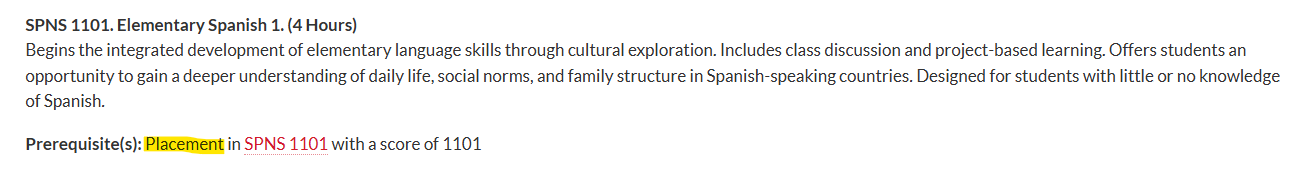

In [49]:
from IPython.display import Image, display
display(Image(filename="Spanish_cycle.png"))